# Portfolio Risk & Optimization

Ce notebook documente une investigation complète du risque de portefeuille. L'objectif n'est pas seulement d'obtenir une VaR ou des poids optimisés : il s'agit de comprendre ce que chaque hypothèse apporte, ce qu'elle masque et comment les résultats peuvent être contrôlés.

Nous travaillerons sur cinq ETF liquides représentant des expositions différentes : actions américaines (`SPY`), actions technologiques (`QQQ`), obligations longues (`TLT`), or (`GLD`) et obligations intermédiaires (`IEF`). La convention est constante dans tout le notebook : une perte est positive et vaut `-rendement`.

Les paramètres restent ceux du projet initial : dix ans d'historique, 252 séances par an, taux sans risque annualisé de 2 %, portefeuille équipondéré, 20 000 scénarios Monte Carlo et contraintes long-only. Ces paramètres sont pédagogiques ; ils devront être validés et adaptés avant tout usage client.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from matplotlib.backends.backend_pdf import PdfPages
from scipy.optimize import minimize
from scipy.stats import norm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebook').exists() and (path / 'README.md').exists())
PROCESSED_DIR = (PROJECT_ROOT / 'data' / 'processed').resolve()
FIGURES_DIR = (PROJECT_ROOT / 'reports' / 'figures').resolve()
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TICKERS = ['SPY', 'QQQ', 'TLT', 'GLD', 'IEF']
START_DATE = (pd.Timestamp.today() - pd.DateOffset(years=10)).strftime('%Y-%m-%d')
END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')
TRADING_DAYS = 252
RISK_FREE_RATE = 0.02
CONFIDENCE_LEVELS = [0.95, 0.99]
MC_SCENARIOS = 20_000
np.random.seed(42)
print(f'Projet: {PROJECT_ROOT}')
print(f'Fenêtre de données: {START_DATE} à {END_DATE}')
print(f'Actifs étudiés: {", ".join(TICKERS)}')

Projet: /workspaces/portfolio-risk-optimization-
Fenêtre de données: 2016-09-22 à 2026-09-22
Actifs étudiés: SPY, QQQ, TLT, GLD, IEF


## 1. Collecte des données : établir une base observable

Avant de mesurer le risque, il faut s'assurer que les prix couvrent les mêmes dates et que la source est reproductible. `yfinance` permet de récupérer directement les cours ajustés ; l'ajustement est important car il intègre les dividendes et les splits dans les rendements. On s'attend à obtenir plusieurs années de séances communes, avec suffisamment d'observations pour estimer des quantiles de queue.

In [2]:
prices_raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False, threads=True)
if prices_raw.empty:
    raise RuntimeError('yfinance n a retourné aucune donnée. Vérifiez la connexion réseau ou réessayez.')
prices = prices_raw['Close'] if isinstance(prices_raw.columns, pd.MultiIndex) else prices_raw[['Close']]
prices = prices.reindex(columns=TICKERS).dropna(how='all').ffill().dropna()
returns = prices.pct_change().dropna()
if returns.shape[0] < 500:
    raise ValueError('Historique insuffisant pour une analyse robuste.')
print(f'{prices.shape[0]:,} observations de prix téléchargées.')
print(f'{returns.shape[0]:,} rendements quotidiens exploitables.')
print(f'Première date commune: {returns.index.min().date()}')
print(f'Dernière date commune: {returns.index.max().date()}')

2,512 observations de prix téléchargées.
2,511 rendements quotidiens exploitables.
Première date commune: 2016-09-23
Dernière date commune: 2026-09-21


## 2. EDA : comprendre la matière première du risque

L'EDA sert à détecter les caractéristiques qui vont guider la suite : dispersion des rendements, trajectoires très différentes et dépendance entre actifs. Les statistiques sont calculées sur les rendements quotidiens puis annualisées avec 252 séances. Cette annualisation est une convention de comparaison, pas une promesse de stabilité dans le temps.

In [3]:
annualized_return = (1 + returns.mean()) ** TRADING_DAYS - 1
annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS)
summary = pd.DataFrame({'Rendement annualisé': annualized_return, 'Volatilité annualisée': annualized_volatility, 'Observations': returns.count()})
print('Statistiques annualisées par actif :')
display(summary.style.format({'Rendement annualisé': '{:.2%}', 'Volatilité annualisée': '{:.2%}'}))

Statistiques annualisées par actif :


,Rendement annualisé,Volatilité annualisée,Observations
Ticker,,,
SPY,17.29%,17.96%,2511
QQQ,24.09%,22.56%,2511
TLT,-1.21%,14.82%,2511
GLD,13.62%,16.37%,2511
IEF,0.54%,6.61%,2511


Les statistiques montrent que la volatilité varie fortement selon la classe d actif.


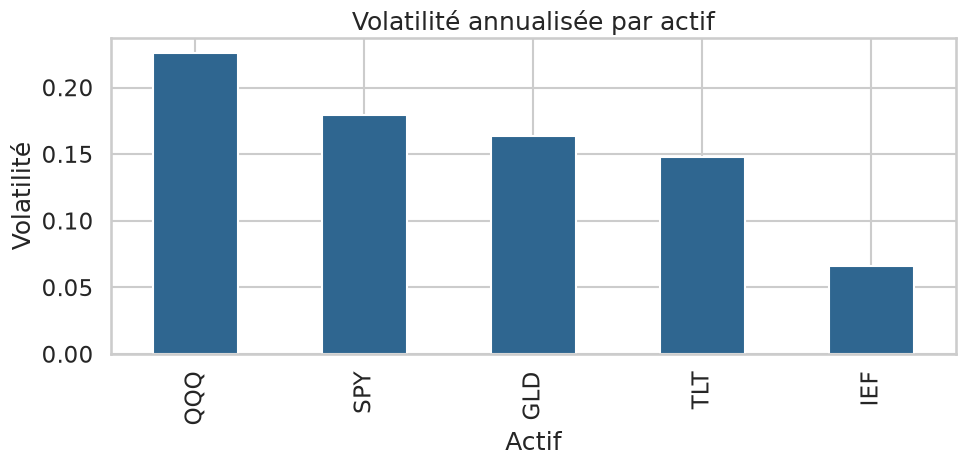

In [4]:
print('Les statistiques montrent que la volatilité varie fortement selon la classe d actif.')
fig, ax = plt.subplots(figsize=(10, 5))
annualized_volatility.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#2f6690', title='Volatilité annualisée par actif')
ax.set_ylabel('Volatilité')
ax.set_xlabel('Actif')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'asset_volatility.png', dpi=160)
plt.show()

### Lecture des statistiques

Une volatilité plus élevée signifie que les pertes quotidiennes peuvent être plus amples, mais elle ne suffit pas à juger la qualité d'un actif. Les obligations et l'or sont intéressants précisément parce que leurs mouvements peuvent différer de ceux des actions. Cette première observation motive l'analyse des corrélations avant de construire un portefeuille.

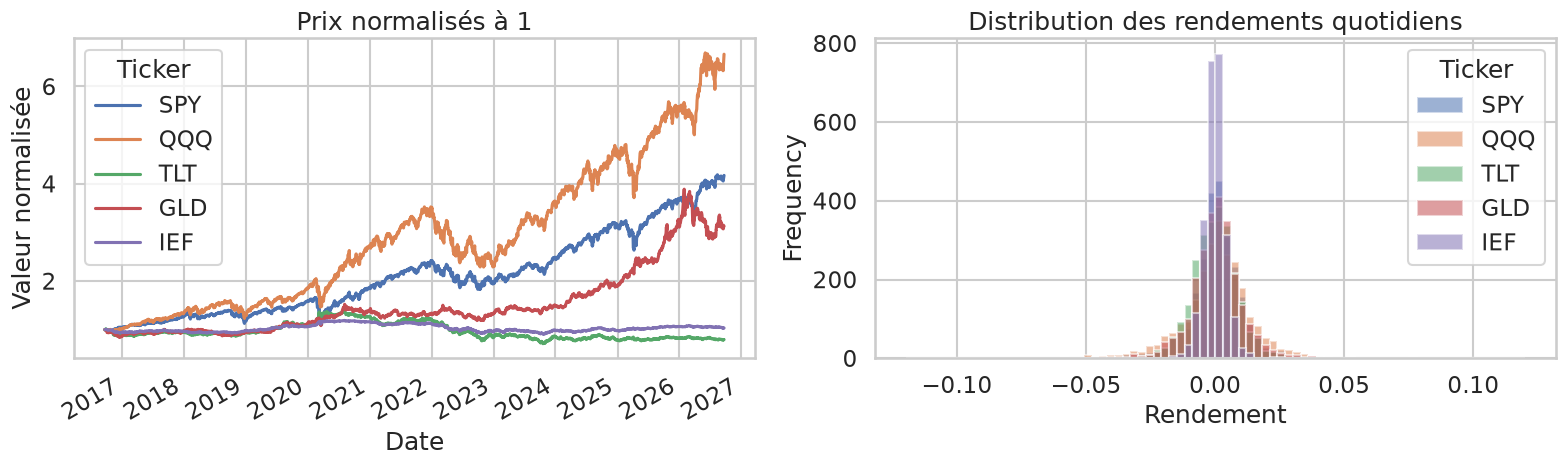

La dispersion et les trajectoires sont maintenant visibles avant toute hypothèse de modèle.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
(prices / prices.iloc[0]).plot(ax=axes[0], title='Prix normalisés à 1')
returns.plot(kind='hist', bins=80, alpha=0.55, ax=axes[1], title='Distribution des rendements quotidiens')
axes[0].set_ylabel('Valeur normalisée')
axes[1].set_xlabel('Rendement')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_prices_returns.png', dpi=160)
plt.show()
print('La dispersion et les trajectoires sont maintenant visibles avant toute hypothèse de modèle.')

### 3. Corrélations : vérifier si la diversification peut fonctionner

La diversification réduit le risque lorsque les actifs ne bougent pas parfaitement ensemble. Une corrélation faible ou négative ne supprime pas les pertes, mais peut amortir la volatilité agrégée. Nous allons donc mesurer directement les dépendances observées avant de fixer l'allocation de référence.

Matrice de corrélation des rendements quotidiens :


Ticker,SPY,QQQ,TLT,GLD,IEF
Ticker,,,,,
SPY,1.00,0.93,-0.14,0.11,-0.11
QQQ,0.93,1.00,-0.08,0.13,-0.06
TLT,-0.14,-0.08,1.00,0.24,0.91
GLD,0.11,0.13,0.24,1.00,0.32
IEF,-0.11,-0.06,0.91,0.32,1.00


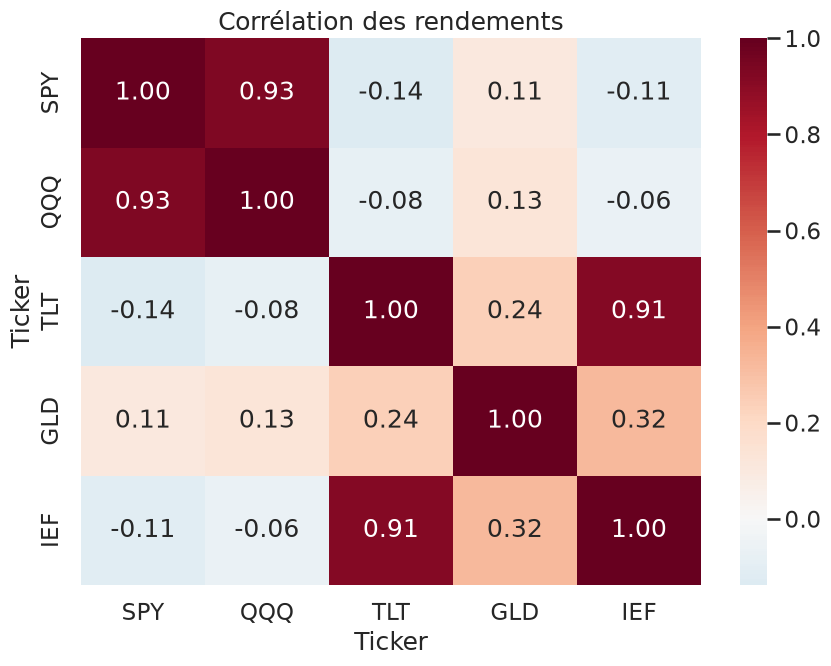

In [6]:
correlation_matrix = returns.corr()
print('Matrice de corrélation des rendements quotidiens :')
display(correlation_matrix.style.format('{:.2f}'))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Corrélation des rendements')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=160)
plt.show()

### Validation de l'EDA et question de risque

La matrice permet de vérifier si les actifs apportent réellement des sources de risque différentes. Une corrélation élevée entre `SPY` et `QQQ` est cohérente avec leur exposition aux actions américaines ; des corrélations plus faibles avec `TLT`, `GLD` ou `IEF` rendent plausible un effet de diversification. Cette observation ne suffit toutefois pas : il faut maintenant traduire les rendements en pertes quantifiées.

## 4. Construire le portefeuille de référence

Un portefeuille équipondéré fournit une base transparente pour comparer les méthodes. Il ne prétend pas être optimal : il sert de portefeuille témoin, afin que les écarts entre modèles de risque proviennent des hypothèses statistiques plutôt que d'une allocation choisie après coup.

In [7]:
weights_equal = np.repeat(1 / len(TICKERS), len(TICKERS))
portfolio_returns = returns.to_numpy() @ weights_equal
portfolio_losses = -portfolio_returns
mean_daily = portfolio_returns.mean()
std_daily = portfolio_returns.std(ddof=1)
print('Allocation de référence :')
print(pd.Series(weights_equal, index=TICKERS).to_string())
print(f'Rendement quotidien moyen: {mean_daily:.4%}')
print(f'Volatilité quotidienne: {std_daily:.4%}')

Allocation de référence :
SPY    0.2
QQQ    0.2
TLT    0.2
GLD    0.2
IEF    0.2
Rendement quotidien moyen: 0.0394%
Volatilité quotidienne: 0.6257%


## 5. VaR historique : commencer par les observations

La VaR historique utilise directement le quantile empirique des pertes observées. Elle ne force pas une forme de distribution et conserve les asymétries présentes dans l'échantillon. À 95 %, environ 5 % des séances devraient dépasser le seuil, sous réserve que le passé soit représentatif. Nous calculons cette méthode séparément pour établir notre référence empirique.

In [8]:
historical_var = {level: float(np.quantile(portfolio_losses, level)) for level in CONFIDENCE_LEVELS}
print('VaR historique :')
for level, value in historical_var.items():
    print(f'  {level:.0%}: {value:.2%}')
assert all(value > 0 for value in historical_var.values()), 'La convention de perte attend une VaR positive.'

VaR historique :
  95%: 1.00%
  99%: 1.61%


### Lecture de la VaR historique

Ce seuil répond à une question concrète : dans 95 % ou 99 % des journées observées, la perte est restée sous cette valeur. Il ne dit pas quelle perte survient après le seuil ; cette limite justifiera le recours au CVaR. Nous allons maintenant comparer cette observation à une hypothèse de normalité.

## 6. VaR paramétrique : tester une hypothèse simplificatrice

La VaR paramétrique remplace la distribution empirique par une loi normale calibrée avec la moyenne et l'écart-type observés. Elle est rapide et lisible, mais la normalité peut sous-estimer les événements extrêmes si les rendements ont des queues épaisses. Cette cellule permet de mesurer précisément ce que cette hypothèse produit.

In [9]:
parametric_var = {level: float(-(mean_daily + std_daily * norm.ppf(1 - level))) for level in CONFIDENCE_LEVELS}
print('VaR paramétrique sous hypothèse normale :')
for level, value in parametric_var.items():
    print(f'  {level:.0%}: {value:.2%}')

VaR paramétrique sous hypothèse normale :
  95%: 0.99%
  99%: 1.42%


### Validation de la VaR paramétrique

La différence avec l'historique est informative : elle reflète l'écart entre une distribution lissée et les observations réellement vues. Si la VaR normale est plus faible, elle peut être optimiste dans la queue ; si elle est plus élevée, la dispersion récente peut dominer les quantiles empiriques. Le troisième calcul introduira l'incertitude d'échantillonnage par simulation.

## 7. VaR Monte Carlo : conserver la dépendance entre actifs

La simulation Monte Carlo tire des rendements selon une normale multivariée calibrée sur les moyennes et la covariance observées. Elle reprend donc l'hypothèse de forme normale, mais permet de propager explicitement la covariance et de réduire la dépendance à un seul quantile historique. Avec 20 000 scénarios, on attend des estimations stables à quelques fluctuations aléatoires près.

In [10]:
covariance = returns.cov().to_numpy()
mc_returns = np.random.multivariate_normal(returns.mean().to_numpy(), covariance, size=MC_SCENARIOS) @ weights_equal
mc_losses = -mc_returns
monte_carlo_var = {level: float(np.quantile(mc_losses, level)) for level in CONFIDENCE_LEVELS}
print(f'{MC_SCENARIOS:,} scénarios Monte Carlo générés.')
for level, value in monte_carlo_var.items():
    print(f'VaR Monte Carlo {level:.0%}: {value:.2%}')

20,000 scénarios Monte Carlo générés.
VaR Monte Carlo 95%: 1.00%
VaR Monte Carlo 99%: 1.42%


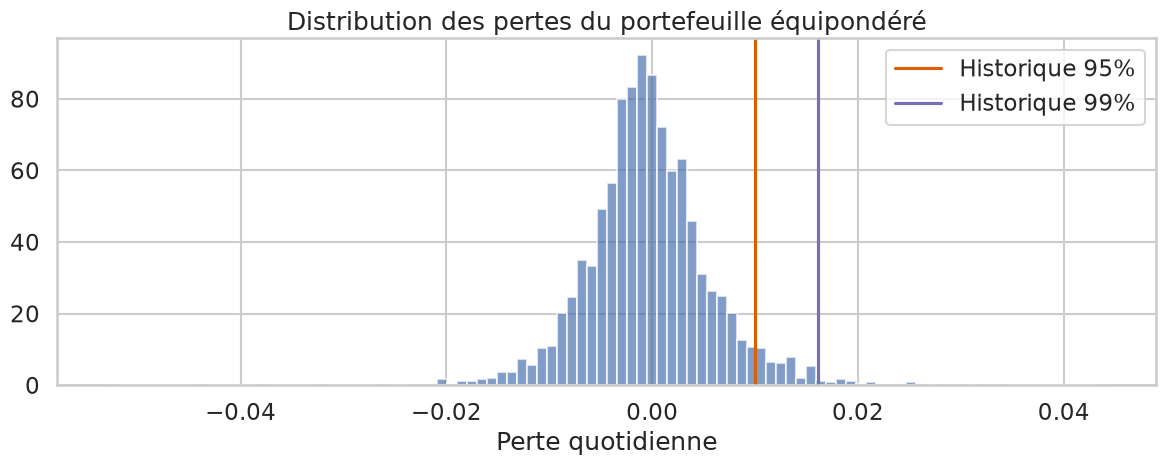

La distribution des pertes et les seuils historiques sont visibles dans la figure enregistrée.


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(portfolio_losses, bins=100, alpha=0.7, density=True)
for level, color in zip(CONFIDENCE_LEVELS, ['#d95f02', '#7570b3']):
    ax.axvline(historical_var[level], color=color, label=f'Historique {level:.0%}')
ax.set_title('Distribution des pertes du portefeuille équipondéré')
ax.set_xlabel('Perte quotidienne')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'var_distribution.png', dpi=160)
plt.show()
print('La distribution des pertes et les seuils historiques sont visibles dans la figure enregistrée.')

## 8. Comparer les trois VaR : le diagnostic de modèle

Un seul chiffre ne permet pas de juger une méthode. Nous comparons les niveaux obtenus et calculons les écarts absolus entre méthodes. Des écarts faibles indiquent des ordres de grandeur convergents ; des écarts importants signalent que la forme de la distribution ou la profondeur de la queue influence fortement la décision.

In [12]:
var_table = pd.DataFrame({'Historique': historical_var, 'Paramétrique': parametric_var, 'Monte Carlo': monte_carlo_var}).T
var_spread = var_table.max() - var_table.min()
print('Comparaison numérique des VaR :')
display(var_table.style.format('{:.2%}'))
print('Écart maximal entre méthodes :')
for level, value in var_spread.items():
    print(f'  {level:.0%}: {value:.2%}')

Comparaison numérique des VaR :


,0.950000,0.990000
Historique,1.00%,1.61%
Paramétrique,0.99%,1.42%
Monte Carlo,1.00%,1.42%


Écart maximal entre méthodes :
  95%: 0.01%
  99%: 0.19%


### Ce que révèle la comparaison

Les trois méthodes ne répondent pas exactement à la même question. L'historique conserve les événements réellement observés, la méthode paramétrique lisse ces observations par une loi normale et Monte Carlo reproduit une distribution multivariée sous cette même forme. Une divergence à 99 % est particulièrement importante pour un investisseur, car elle concerne les scénarios rares où le capital est le plus vulnérable.

## 9. Backtesting : confronter le modèle aux dépassements observés

La théorie prévoit environ $(1-c)\times N$ dépassements pour une VaR au niveau de confiance $c$ sur $N$ jours. Ce contrôle simple ne prouve pas que le modèle est correct, mais il révèle immédiatement une sous-estimation ou une sur-estimation systématique du risque. C'est la correction méthodologique attendue lorsqu'une hypothèse de normalité semble trop optimiste.

In [13]:
backtest_rows = []
for level in CONFIDENCE_LEVELS:
    expected = (1 - level) * len(portfolio_losses)
    row = {'niveau': level, 'depassements_observes': int((portfolio_losses > parametric_var[level]).sum()), 'depassements_attendus': expected}
    row['taux_observe'] = row['depassements_observes'] / len(portfolio_losses)
    backtest_rows.append(row)
backtest = pd.DataFrame(backtest_rows).set_index('niveau')
print('Backtesting de la VaR paramétrique :')
display(backtest.style.format({'taux_observe': '{:.2%}', 'depassements_attendus': '{:.1f}'}))

Backtesting de la VaR paramétrique :


,depassements_observes,depassements_attendus,taux_observe
niveau,,,
0.950000,129,125.6,5.14%
0.990000,44,25.1,1.75%


### Validation du backtesting

Si le nombre observé dépasse nettement le nombre attendu, la VaR paramétrique sous-estime le risque et l'hypothèse normale doit être traitée avec prudence. Si l'écart est faible, cela ne valide pas définitivement le modèle : un historique de dix ans contient peu d'observations réellement extrêmes. Dans les deux cas, la VaR ne décrit pas la gravité moyenne des pertes au-delà du seuil.

## 10. CVaR : mesurer la profondeur de la queue

Le CVaR, ou Expected Shortfall, est la perte moyenne conditionnelle aux jours où la perte dépasse la VaR historique. Il complète donc un seuil par une information de sévérité, particulièrement utile pour dimensionner des réserves ou expliquer un scénario défavorable à un client.

In [14]:
cvar = {level: float(portfolio_losses[portfolio_losses >= historical_var[level]].mean()) for level in CONFIDENCE_LEVELS}
print('CVaR historique :')
for level, value in cvar.items():
    print(f'  {level:.0%}: {value:.2%}')
print('La CVaR est supérieure ou égale à la VaR, comme attendu pour une moyenne de pertes de queue.')

CVaR historique :
  95%: 1.45%
  99%: 2.28%
La CVaR est supérieure ou égale à la VaR, comme attendu pour une moyenne de pertes de queue.


### Validation du CVaR

La CVaR doit être au moins aussi élevée que la VaR, puisque la moyenne porte sur les pertes les plus défavorables. L'écart entre les deux chiffres quantifie la profondeur de la queue : une différence importante signifie que franchir le seuil peut conduire à une perte sensiblement plus sévère que le seuil lui-même.

## 11. Archiver les métriques de risque

Les résultats sont écrits dans un JSON léger afin que le dashboard et le rapport PDF utilisent exactement les valeurs calculées ici. Cette séparation évite de recopier manuellement des chiffres dans les livrables.

In [15]:
risk_metrics = {
    'sample_start': str(returns.index.min().date()),
    'sample_end': str(returns.index.max().date()),
    'assets': TICKERS,
    'equal_weight': weights_equal.tolist(),
    'risk_free_rate': RISK_FREE_RATE,
    'annualized_return': float((1 + mean_daily) ** TRADING_DAYS - 1),
    'annualized_volatility': float(std_daily * np.sqrt(TRADING_DAYS)),
    'var_historical': {str(k): v for k, v in historical_var.items()},
    'var_parametric': {str(k): v for k, v in parametric_var.items()},
    'var_monte_carlo': {str(k): v for k, v in monte_carlo_var.items()},
    'cvar_historical': {str(k): v for k, v in cvar.items()}
}
with (PROCESSED_DIR / 'risk_metrics.json').open('w', encoding='utf-8') as file:
    json.dump(risk_metrics, file, indent=2)
print(f'Métriques archivées dans: {PROCESSED_DIR / "risk_metrics.json"}')
print(f'Rendement annualisé de référence: {risk_metrics["annualized_return"]:.2%}')
print(f'Volatilité annualisée de référence: {risk_metrics["annualized_volatility"]:.2%}')

Métriques archivées dans: /workspaces/portfolio-risk-optimization-/data/processed/risk_metrics.json
Rendement annualisé de référence: 10.44%
Volatilité annualisée de référence: 9.93%


## 12. Contribution au risque par actif

La corrélation ne suffit pas pour dire quel actif porte le risque du portefeuille. Avec $\sigma_p = \sqrt{w^T\Sigma w}$, la contribution au risque de l'actif $i$ est $w_i(\Sigma w)_i / \sigma_p$. Cette décomposition respecte la volatilité totale et permet d'identifier l'actif qui diversifie le plus ou concentre le plus le risque.

In [16]:
covariance_daily = returns.cov().to_numpy()
portfolio_volatility_daily = float(np.sqrt(weights_equal @ covariance_daily @ weights_equal))
absolute_risk_contribution = weights_equal * (covariance_daily @ weights_equal) / portfolio_volatility_daily
relative_risk_contribution = absolute_risk_contribution / portfolio_volatility_daily
risk_contribution = pd.DataFrame({'Contribution absolue': absolute_risk_contribution, 'Contribution relative': relative_risk_contribution}, index=TICKERS)
print('Contribution au risque du portefeuille équipondéré :')
display(risk_contribution.style.format({'Contribution absolue': '{:.4%}', 'Contribution relative': '{:.2%}'}))
print(f'Somme des contributions relatives: {relative_risk_contribution.sum():.2%}')

Contribution au risque du portefeuille équipondéré :


,Contribution absolue,Contribution relative
SPY,0.1731%,27.66%
QQQ,0.2272%,36.30%
TLT,0.0769%,12.29%
GLD,0.1116%,17.83%
IEF,0.0370%,5.91%


Somme des contributions relatives: 100.00%


### Visualiser la concentration du risque

Un actif peut avoir un poids égal aux autres tout en contribuant davantage à la volatilité, selon sa propre dispersion et ses covariances. Le graphique suivant rend cette asymétrie lisible : une faible contribution relative indique un rôle davantage diversifiant dans cette allocation précise, tandis qu'une contribution élevée signale un moteur de risque.

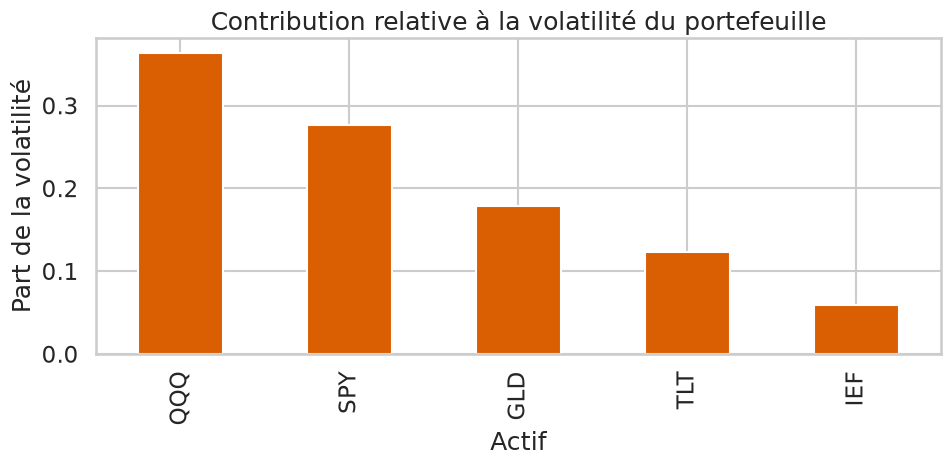

Actif contribuant le plus: QQQ
Actif contribuant le moins: IEF


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
risk_contribution['Contribution relative'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='#d95f02', title='Contribution relative à la volatilité du portefeuille')
ax.set_ylabel('Part de la volatilité')
ax.set_xlabel('Actif')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'risk_contribution.png', dpi=160)
plt.show()
print(f'Actif contribuant le plus: {risk_contribution["Contribution relative"].idxmax()}')
print(f'Actif contribuant le moins: {risk_contribution["Contribution relative"].idxmin()}')

### Lecture de la contribution au risque

La somme des contributions relatives doit être égale à 100 %, ce qui constitue un contrôle interne utile. L'actif avec la plus forte contribution est le principal moteur de volatilité dans le portefeuille de référence ; l'actif avec la plus faible contribution est le meilleur candidat à un rôle de stabilisation, sans que cela implique une performance future garantie.

## 13. Optimisation de Markowitz

L'optimisation répond maintenant à une question différente : quelles allocations long-only auraient minimisé la volatilité ou maximisé le ratio de Sharpe selon les mêmes rendements et covariances ? Cette distinction est importante : on ne corrige pas rétroactivement le portefeuille témoin, on compare une allocation de référence à des solutions soumises à des contraintes explicites.

In [18]:
mean_annual = returns.mean().to_numpy() * TRADING_DAYS
cov_annual = returns.cov().to_numpy() * TRADING_DAYS
asset_count = len(TICKERS)
bounds = tuple((0.0, 1.0) for _ in range(asset_count))
constraint = {'type': 'eq', 'fun': lambda weights: weights.sum() - 1}
def portfolio_stats(weights):
    annual_return = float(weights @ mean_annual)
    annual_volatility = float(np.sqrt(weights @ cov_annual @ weights))
    sharpe = (annual_return - RISK_FREE_RATE) / annual_volatility
    return annual_return, annual_volatility, float(sharpe)
def optimize(objective, initial=None):
    result = minimize(objective, initial if initial is not None else weights_equal, method='SLSQP', bounds=bounds, constraints=constraint, options={'maxiter': 1000, 'ftol': 1e-10})
    if not result.success:
        raise RuntimeError(result.message)
    return result.x
print('Fonctions de performance et contraintes long-only initialisées.')
print(f'Nombre d actifs: {asset_count}; somme des poids de départ: {weights_equal.sum():.1f}')

Fonctions de performance et contraintes long-only initialisées.
Nombre d actifs: 5; somme des poids de départ: 1.0


### Portefeuille de variance minimale

Le premier objectif est de réduire la volatilité annualisée sous la contrainte que tous les poids restent entre 0 et 1 et qu'ils totalisent 100 %. Le résultat est une allocation historique optimale au sens du modèle, pas une vérité économique : il doit être interprété avec la sensibilité des estimations en tête.

In [19]:
minimum_variance_weights = optimize(lambda weights: portfolio_stats(weights)[1])
minimum_variance = portfolio_stats(minimum_variance_weights)
print('Portefeuille de variance minimale :')
print(pd.Series(minimum_variance_weights, index=TICKERS).to_string())
print(f'Rendement annualisé: {minimum_variance[0]:.2%}')
print(f'Volatilité annualisée: {minimum_variance[1]:.2%}')
print(f'Ratio de Sharpe: {minimum_variance[2]:.2f}')

Portefeuille de variance minimale :
SPY    1.438077e-01
QQQ    2.038190e-20
TLT    1.330098e-17
GLD    4.933854e-03
IEF    8.512585e-01
Rendement annualisé: 2.82%
Volatilité annualisée: 5.96%
Ratio de Sharpe: 0.14


### Portefeuille de Sharpe maximal

Le second objectif maximise le rendement excédentaire par unité de volatilité, avec un taux sans risque de 2 %. Ce critère favorise un compromis rendement-risque dans l'échantillon ; il peut être plus sensible que la variance minimale aux erreurs d'estimation des rendements moyens.

In [20]:
maximum_sharpe_weights = optimize(lambda weights: -portfolio_stats(weights)[2])
maximum_sharpe = portfolio_stats(maximum_sharpe_weights)
print('Portefeuille de Sharpe maximal :')
print(pd.Series(maximum_sharpe_weights, index=TICKERS).to_string())
print(f'Rendement annualisé: {maximum_sharpe[0]:.2%}')
print(f'Volatilité annualisée: {maximum_sharpe[1]:.2%}')
print(f'Ratio de Sharpe: {maximum_sharpe[2]:.2f}')

Portefeuille de Sharpe maximal :
SPY    7.760715e-17
QQQ    5.092472e-01
TLT    7.046016e-17
GLD    4.907528e-01
IEF    0.000000e+00
Rendement annualisé: 17.26%
Volatilité annualisée: 14.82%
Ratio de Sharpe: 1.03


## 14. Frontière efficiente : visualiser les compromis

La frontière relie des portefeuilles qui minimisent la volatilité pour une cible de rendement donnée. Elle permet de replacer les deux solutions précédentes dans un ensemble de compromis, plutôt que de présenter un optimum isolé. Nous vérifierons ensuite que les contraintes de somme des poids sont respectées.

In [21]:
target_returns = np.linspace(mean_annual.min(), mean_annual.max(), 40)
frontier_points = []
for target in target_returns:
    result = minimize(lambda weights: portfolio_stats(weights)[1], weights_equal, method='SLSQP', bounds=bounds, constraints=[constraint, {'type': 'eq', 'fun': lambda weights, target=target: weights @ mean_annual - target}], options={'maxiter': 1000})
    if result.success:
        annual_return, annual_volatility, sharpe = portfolio_stats(result.x)
        frontier_points.append({'return': annual_return, 'volatility': annual_volatility, 'sharpe': sharpe, 'weights': result.x.tolist()})
frontier_frame = pd.DataFrame(frontier_points)
print(f'{len(frontier_frame)} points de frontière calculés sur {len(target_returns)} cibles.')
print(f'Plage de rendements ciblés: {target_returns.min():.2%} à {target_returns.max():.2%}')

40 points de frontière calculés sur 40 cibles.
Plage de rendements ciblés: -1.22% à 21.59%


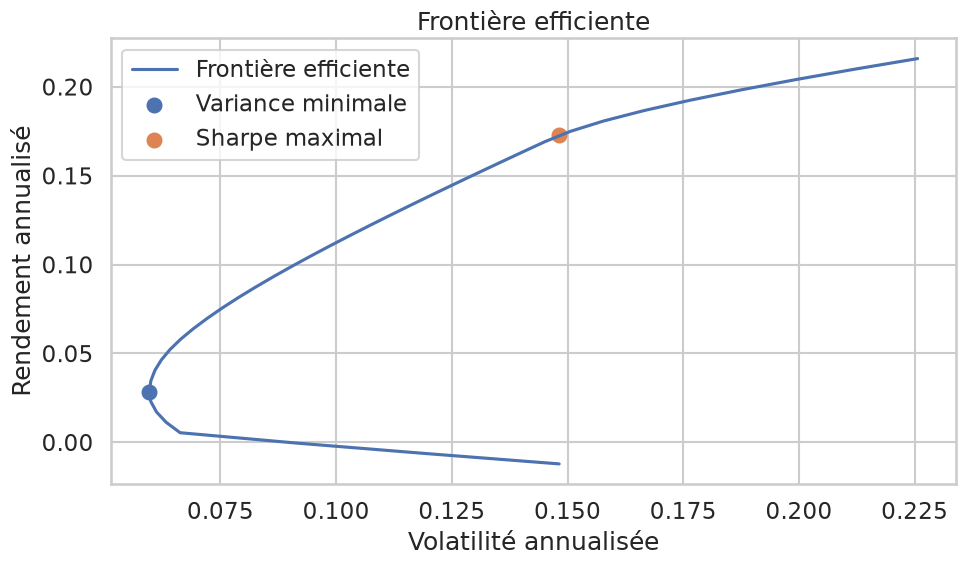

Résultats d optimisation archivés dans: /workspaces/portfolio-risk-optimization-/data/processed/optimization_results.json


In [22]:
optimization_results = {'assets': TICKERS, 'frontier': {key: frontier_frame[key].tolist() for key in ['return', 'volatility', 'sharpe']}, 'minimum_variance': {'weights': minimum_variance_weights.tolist(), 'return': minimum_variance[0], 'volatility': minimum_variance[1], 'sharpe': minimum_variance[2]}, 'maximum_sharpe': {'weights': maximum_sharpe_weights.tolist(), 'return': maximum_sharpe[0], 'volatility': maximum_sharpe[1], 'sharpe': maximum_sharpe[2]}}
with (PROCESSED_DIR / 'optimization_results.json').open('w', encoding='utf-8') as file:
    json.dump(optimization_results, file, indent=2)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frontier_frame['volatility'], frontier_frame['return'], label='Frontière efficiente')
ax.scatter(minimum_variance[1], minimum_variance[0], s=100, label='Variance minimale')
ax.scatter(maximum_sharpe[1], maximum_sharpe[0], s=100, label='Sharpe maximal')
ax.set(xlabel='Volatilité annualisée', ylabel='Rendement annualisé', title='Frontière efficiente')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'efficient_frontier.png', dpi=160)
plt.show()
print(f'Résultats d optimisation archivés dans: {PROCESSED_DIR / "optimization_results.json"}')

### Validation de Markowitz

Les poids respectent les contraintes long-only et la somme égale à 1. La frontière est cohérente si une hausse de rendement cible s'accompagne généralement d'une volatilité plus élevée. Cette structure est une conséquence des paramètres historiques, pas une prévision : elle doit être complétée par des scénarios de crise observés.

## 15. Stress testing : revenir à des épisodes concrets

Les scénarios historiques ne sont pas des prévisions, mais ils donnent une échelle de perte compréhensible. Nous reprenons les fenêtres de la crise financière de 2008 et du choc COVID de 2020 et appliquons la même allocation équipondérée, afin de comparer les scénarios à la VaR quotidienne.

In [23]:
stress_windows = {'Crise financière 2008': ('2008-09-01', '2009-03-31'), 'Krach COVID 2020': ('2020-02-19', '2020-03-23')}
stress_prices_raw = yf.download(TICKERS, start='2007-01-01', end=END_DATE, auto_adjust=True, progress=False, threads=True)['Close']
stress_prices = stress_prices_raw.reindex(columns=TICKERS).ffill().dropna()
stress_returns = stress_prices.pct_change().dropna()
print(f'Historique de stress disponible du {stress_returns.index.min().date()} au {stress_returns.index.max().date()}.')
print(f'Scénarios préparés: {", ".join(stress_windows)}')

Historique de stress disponible du 2007-01-04 au 2026-09-21.
Scénarios préparés: Crise financière 2008, Krach COVID 2020


In [24]:
stress_results = {}
for scenario, (start, end) in stress_windows.items():
    window = stress_returns.loc[start:end]
    if window.empty:
        raise ValueError(f'Aucune donnée disponible pour le scénario {scenario}.')
    stress_results[scenario] = {'start': start, 'end': end, 'observations': int(len(window)), 'portfolio_return': float((1 + window.to_numpy() @ weights_equal).prod() - 1)}
stress_table = pd.DataFrame(stress_results).T
print('Performance cumulée du portefeuille équipondéré pendant les scénarios :')
display(stress_table.style.format({'portfolio_return': '{:.2%}'}))

Performance cumulée du portefeuille équipondéré pendant les scénarios :


,start,end,observations,portfolio_return
Crise financière 2008,2008-09-01,2009-03-31,146,-7.06%
Krach COVID 2020,2020-02-19,2020-03-23,24,-9.47%


### Validation des scénarios

Une perte cumulée de crise ne se compare pas directement à une VaR quotidienne : l'horizon et la dépendance temporelle sont différents. Elle est néanmoins utile pour expliquer à un investisseur pourquoi une mesure ponctuelle doit être complétée par des scénarios prolongés. Le JSON suivant permettra au dashboard de réutiliser ces résultats sans saisie manuelle.

In [25]:
with (PROCESSED_DIR / 'stress_results.json').open('w', encoding='utf-8') as file:
    json.dump(stress_results, file, indent=2)
print(f'Résultats de stress archivés dans: {PROCESSED_DIR / "stress_results.json"}')
print(f'Pire scénario observé: {stress_table["portfolio_return"].idxmin()}')

Résultats de stress archivés dans: /workspaces/portfolio-risk-optimization-/data/processed/stress_results.json
Pire scénario observé: Krach COVID 2020


## 16. Génération du rapport PDF

Le rapport final doit être une sortie du calcul, pas une transcription manuelle. Nous réutilisons donc `risk_metrics`, `optimization_results`, `stress_results` et les figures déjà sauvegardées. La mise en page utilise `reportlab` — page de garde, résumé exécutif sous forme de tableau, sections illustrées et page de limites/conclusion — pour rester cohérent avec le format des projets 1 et 2 du portfolio. Ainsi, une nouvelle exécution du notebook met à jour le PDF avec les mêmes valeurs que le dashboard.

In [ ]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, Image, PageBreak, HRFlowable)
from PIL import Image as PILImage

NAVY = colors.HexColor('#1B2A4A')
STEEL = colors.HexColor('#2f6690')
GREY = colors.HexColor('#6B7280')
LIGHT_BG = colors.HexColor('#F3F4F6')

styles = getSampleStyleSheet()
styles.add(ParagraphStyle('CoverTitle', fontSize=26, leading=30, textColor=NAVY, fontName='Helvetica-Bold', spaceAfter=6))
styles.add(ParagraphStyle('CoverSubtitle', fontSize=13, leading=17, textColor=GREY, fontName='Helvetica'))
styles.add(ParagraphStyle('SectionTitle', fontSize=15, leading=18, textColor=NAVY, fontName='Helvetica-Bold', spaceBefore=4, spaceAfter=8))
styles.add(ParagraphStyle('Body', fontSize=10, leading=14.5, textColor=colors.HexColor('#1F2937')))
styles.add(ParagraphStyle('Caption', fontSize=8.5, leading=11, textColor=GREY, alignment=1, spaceBefore=2, spaceAfter=10))
styles.add(ParagraphStyle('TableCell', fontSize=9.5, leading=12, fontName='Helvetica'))
styles.add(ParagraphStyle('TableHeader', fontSize=9.5, leading=12, fontName='Helvetica-Bold', textColor=colors.white))

def P(text, style_name='TableCell'):
    return Paragraph(text, styles[style_name])

report_path = PROJECT_ROOT / 'reports' / 'final_report.pdf'
print('Styles reportlab initialisés.')
print(f'Rapport cible: {report_path}')

### Page de garde et résumé exécutif

La page de garde situe le document (période, univers d'actifs, portefeuille de référence). Le résumé exécutif rassemble en un seul tableau les indicateurs calculés plus haut — VaR sous ses trois formes, CVaR, ratios de Sharpe des portefeuilles optimisés — pour une lecture rapide avant le détail méthodologique qui suit.

In [ ]:
story = []
story.append(Spacer(1, 3*cm))
story.append(Paragraph('Portfolio Risk &amp; Optimization', styles['CoverTitle']))
story.append(Paragraph('Rapport exécutif — VaR, CVaR, optimisation de Markowitz et stress testing', styles['CoverSubtitle']))
story.append(Spacer(1, 0.4*cm))
story.append(HRFlowable(width='100%', color=STEEL, thickness=1))
story.append(Spacer(1, 0.4*cm))
story.append(Paragraph(
    f"Période analysée : {risk_metrics['sample_start']} au {risk_metrics['sample_end']}<br/>"
    f"Univers d'actifs : {', '.join(risk_metrics['assets'])}<br/>"
    f"Portefeuille de référence : équipondéré, contraintes long-only<br/>"
    f"Document pédagogique — aucune recommandation personnalisée", styles['Body']))
story.append(PageBreak())

story.append(Paragraph('Résumé exécutif', styles['SectionTitle']))
summary_rows = [
    [P('Indicateur', 'TableHeader'), P('Valeur', 'TableHeader')],
    [P('Rendement annualisé (référence)'), P(f"{risk_metrics['annualized_return']:.2%}")],
    [P('Volatilité annualisée (référence)'), P(f"{risk_metrics['annualized_volatility']:.2%}")],
    [P('VaR historique 95% / 99%'),
     P(f"{risk_metrics['var_historical']['0.95']:.2%} / {risk_metrics['var_historical']['0.99']:.2%}")],
    [P('VaR paramétrique 95% / 99%'),
     P(f"{risk_metrics['var_parametric']['0.95']:.2%} / {risk_metrics['var_parametric']['0.99']:.2%}")],
    [P('VaR Monte Carlo 95% / 99%'),
     P(f"{risk_metrics['var_monte_carlo']['0.95']:.2%} / {risk_metrics['var_monte_carlo']['0.99']:.2%}")],
    [P('CVaR historique 95% / 99%'),
     P(f"{risk_metrics['cvar_historical']['0.95']:.2%} / {risk_metrics['cvar_historical']['0.99']:.2%}")],
    [P('Sharpe — variance minimale'), P(f"{optimization_results['minimum_variance']['sharpe']:.2f}")],
    [P('Sharpe — Sharpe maximal'), P(f"{optimization_results['maximum_sharpe']['sharpe']:.2f}")],
]
table = Table(summary_rows, colWidths=[9*cm, 6*cm])
table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), NAVY),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9.5),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, LIGHT_BG]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#D1D5DB')),
    ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
    ('TOPPADDING', (0,0), (-1,-1), 6),
    ('BOTTOMPADDING', (0,0), (-1,-1), 6),
]))
story.append(table)
story.append(Spacer(1, 0.4*cm))
story.append(Paragraph(
    "Lecture : les trois méthodes de VaR donnent des ordres de grandeur comparables ; la CVaR, "
    "supérieure à la VaR par construction, quantifie la sévérité au-delà du seuil. Le portefeuille "
    "de Sharpe maximal affiche un ratio plus élevé que la variance minimale, au prix d'une volatilité accrue.",
    styles['Body']))
story.append(PageBreak())
print(f'Page de garde + résumé exécutif construits ({len(story)} éléments).')

### Sections illustrées

Chaque section reprend deux figures déjà sauvegardées dans `reports/figures/`, avec leur légende, en préservant le ratio réel de chaque image. Regrouper deux graphiques par page permet de tenir un rapport complet en 6 à 7 pages, sans page incomplète ni image déformée.

In [ ]:
MAX_IMG_WIDTH = 15 * cm
MAX_IMG_HEIGHT = 8.5 * cm  # garantit que 2 figures tiennent sur une page

def figure_page(title, items):
    """items: liste de (fichier_png, légende). Le ratio réel de chaque PNG est préservé."""
    block = [Paragraph(title, styles['SectionTitle'])]
    for filename, caption in items:
        img_path = FIGURES_DIR / filename
        native_w, native_h = PILImage.open(img_path).size
        ratio = native_w / native_h
        width, height = MAX_IMG_WIDTH, MAX_IMG_WIDTH / ratio
        if height > MAX_IMG_HEIGHT:
            height, width = MAX_IMG_HEIGHT, MAX_IMG_HEIGHT * ratio
        block.append(Image(str(img_path), width=width, height=height, hAlign='CENTER'))
        block.append(Paragraph(caption, styles['Caption']))
    return block

story += figure_page('Analyse exploratoire des actifs', [
    ('eda_prices_returns.png', "Trajectoires normalisées et distribution des rendements quotidiens."),
    ('correlation_matrix.png', "Corrélations entre actifs : base de l'effet de diversification."),
])
story.append(PageBreak())

story += figure_page('Risque du portefeuille de référence', [
    ('asset_volatility.png', "Volatilité annualisée par actif."),
    ('var_distribution.png', "Distribution des pertes et seuils de VaR historique."),
])
story.append(PageBreak())

story += figure_page('Optimisation et concentration du risque', [
    ('risk_contribution.png', "Contribution relative de chaque actif à la volatilité du portefeuille."),
    ('efficient_frontier.png', "Frontière efficiente et portefeuilles remarquables (variance min., Sharpe max.)."),
])
story.append(PageBreak())
print(f'Pages de figures construites ({len(story)} éléments cumulés).')

### Stress testing, limites et conclusion

La dernière page regroupe les résultats des scénarios de crise, les limites méthodologiques et la conclusion. Les regrouper sur une seule page évite une page de conclusion presque vide, tout en gardant chaque élément lisible séparément.

In [ ]:
story.append(Paragraph('Stress testing et conclusion', styles['SectionTitle']))

stress_rows = [[P('Scénario', 'TableHeader'), P('Fenêtre', 'TableHeader'),
                 P('Perte cumulée du portefeuille', 'TableHeader')]]
for scenario, values in stress_results.items():
    stress_rows.append([P(scenario), P(f"{values['start']} → {values['end']}"),
                         P(f"{values['portfolio_return']:.2%}")])
stress_table = Table(stress_rows, colWidths=[5*cm, 5.5*cm, 4.5*cm])
stress_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), STEEL),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9.5),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, LIGHT_BG]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#D1D5DB')),
    ('TOPPADDING', (0,0), (-1,-1), 6),
    ('BOTTOMPADDING', (0,0), (-1,-1), 6),
]))
story.append(stress_table)
story.append(Spacer(1, 0.5*cm))

story.append(Paragraph('Limites', styles['SectionTitle']))
story.append(Paragraph(
    "Les rendements passés ne préjugent pas des rendements futurs. L'hypothèse de normalité "
    "sous-estime les queues épaisses. L'optimisation de Markowitz est instable sur un historique "
    "court et sensible aux erreurs d'estimation des rendements moyens. Les ETF utilisés sont des "
    "proxies de classes d'actifs, non des garanties de performance.", styles['Body']))
story.append(Spacer(1, 0.3*cm))

story.append(Paragraph('Conclusion et actions recommandées', styles['SectionTitle']))
story.append(Paragraph(
    "Les trois méthodes de VaR convergent en ordre de grandeur mais divergent dans la queue de "
    "distribution, ce qui justifie de toujours compléter la VaR par la CVaR et des scénarios de "
    "crise. Prochaines étapes : validation walk-forward avec coûts de transaction, contraintes de "
    "poids et optimisation robuste, recalibration régulière selon le mandat.", styles['Body']))
print(f'Stress testing + limites + conclusion construits ({len(story)} éléments cumulés).')

In [ ]:
def add_footer(canvas, doc):
    canvas.saveState()
    canvas.setFont('Helvetica', 8)
    canvas.setFillColor(GREY)
    canvas.drawCentredString(A4[0]/2, 1.2*cm,
                              f"Portfolio Risk & Optimization — document pédagogique — page {doc.page}")
    canvas.restoreState()

doc = SimpleDocTemplate(str(report_path), pagesize=A4,
                         leftMargin=2*cm, rightMargin=2*cm, topMargin=2*cm, bottomMargin=2*cm)
doc.build(story, onFirstPage=add_footer, onLaterPages=add_footer)
print(f'Rapport généré: {report_path}')